[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_06/06_01_fundamentos_e_kmeans.ipynb)

# Unidade VI — Análise de Grupos

## Fundamentos e k-means

**Carga estimada:** 4 horas  
**Pré-requisitos:** atributos numéricos, distância Euclidiana, normalização e visualização de dados.

> **Pergunta norteadora:** como formar grupos sem rótulos prévios e o que exatamente significa dizer que dois objetos pertencem ao mesmo grupo?

Agrupamento (*clustering*) é uma tarefa descritiva. O algoritmo organiza objetos segundo uma representação e um critério de proximidade; ele não descobre automaticamente categorias verdadeiras ou naturais.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir agrupamento de classificação;
- explicar por que representação, atributos e distância definem a noção de grupo;
- interpretar centroide, atribuição, atualização e convergência;
- calcular manualmente uma iteração do k-means;
- interpretar a soma dos quadrados dentro dos grupos;
- demonstrar como a escala altera uma partição;
- explicar o papel de $k$, da inicialização e de múltiplas execuções;
- reconhecer limitações relativas a geometria, ruído e interpretação.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Agrupamento não é classificação

| Aspecto | Classificação | Agrupamento |
|---|---|---|
| Rótulo conhecido no treino | sim | não |
| Pergunta | qual classe atribuir? | quais objetos são semelhantes segundo um critério? |
| Avaliação | compara previsão com rótulo ou custo | examina coesão, separação, estabilidade e utilidade |
| Resultado | classes previstas | grupos dependentes da representação |

Sem rótulos, não existe uma resposta única esperando ser recuperada. Os mesmos clientes podem ser agrupados por comportamento de compra, localização ou uso do serviço. Cada escolha responde a uma pergunta diferente.

## 2. Antes do algoritmo: definir o que significa ser parecido

Uma análise de grupos exige decisões sobre:

1. **unidade de análise:** cliente, compra, produto ou período?
2. **atributos:** quais características devem aproximar objetos?
3. **representação:** valores brutos, proporções, perfis temporais ou componentes?
4. **escala:** uma unidade de renda deve pesar como uma visita?
5. **distância:** proximidade Euclidiana representa o problema?
6. **uso:** que decisão ou investigação os grupos apoiarão?

Incluir um identificador, atributo redundante ou medida de grande amplitude pode criar grupos matematicamente compactos, porém substantivamente vazios.

## 3. Intuição do k-means

O k-means divide $n$ objetos numéricos em $k$ grupos exclusivos. Cada grupo é representado por seu **centroide**, a média de seus pontos.

O algoritmo alterna dois passos:

1. **atribuição:** cada objeto vai para o centroide mais próximo;
2. **atualização:** cada centroide passa a ser a média dos objetos atribuídos.

Os passos se repetem até que as atribuições parem de mudar, os centroides quase não se movam ou um limite de iterações seja alcançado.

A palavra *means* refere-se às médias. Por isso, o método é naturalmente associado a atributos numéricos e distância Euclidiana.

### O que o algoritmo procura reduzir?

Para grupos $C_1,\ldots,C_k$ e centroides $\boldsymbol{\mu}_1,\ldots,\boldsymbol{\mu}_k$, a soma dos quadrados dentro dos grupos é

$$
SSE=\sum_{j=1}^{k}\sum_{\mathbf{x}_i\in C_j}
\lVert\mathbf{x}_i-\boldsymbol{\mu}_j\rVert^2.
$$

Cada termo é a distância Euclidiana ao quadrado entre um objeto e o centroide de seu grupo. Quanto menor a SSE, mais próximos os objetos estão dos respectivos centroides.

A SSE sempre diminui ou permanece igual durante as iterações, mas o algoritmo pode terminar em uma solução local dependente dos centroides iniciais.

## 4. Uma iteração passo a passo

Usaremos seis pontos em duas dimensões e dois centroides iniciais. As letras apenas identificam os objetos; não são rótulos de grupo.

In [2]:
pontos = pd.DataFrame({
    "objeto": list("ABCDEF"),
    "x": [1.0, 1.5, 2.0, 6.0, 6.5, 7.0],
    "y": [1.0, 2.0, 1.2, 5.0, 5.8, 5.2],
})
centroides_iniciais = np.array([
    [1.0, 1.0],
    [6.0, 5.0],
])
pontos

,objeto,x,y
0,A,1.0,1.0
1,B,1.5,2.0
2,C,2.0,1.2
3,D,6.0,5.0
4,E,6.5,5.8
5,F,7.0,5.2


In [3]:
matriz_pontos = pontos[["x", "y"]].to_numpy()
distancias = np.linalg.norm(
    matriz_pontos[:, None, :] - centroides_iniciais[None, :, :],
    axis=2,
)
grupos = distancias.argmin(axis=1)

tabela_atribuicao = pontos.copy()
tabela_atribuicao["distancia_centroide_0"] = distancias[:, 0]
tabela_atribuicao["distancia_centroide_1"] = distancias[:, 1]
tabela_atribuicao["grupo_atribuido"] = grupos

centroides_atualizados = np.vstack([
    matriz_pontos[grupos == grupo].mean(axis=0)
    for grupo in range(2)
])

sse_inicial = sum(
    np.square(
        matriz_pontos[i] - centroides_iniciais[grupos[i]]
    ).sum()
    for i in range(len(pontos))
)
sse_atualizada = sum(
    np.square(
        matriz_pontos[i] - centroides_atualizados[grupos[i]]
    ).sum()
    for i in range(len(pontos))
)

display(tabela_atribuicao.round(3))
display(pd.DataFrame(
    centroides_atualizados,
    columns=["x", "y"],
    index=["centroide_0", "centroide_1"],
).round(3))
pd.DataFrame({
    "momento": ["antes da atualização", "depois da atualização"],
    "SSE": [sse_inicial, sse_atualizada],
}).round(3)

,objeto,x,y,distancia_centroide_0,distancia_centroide_1,grupo_atribuido
0,A,1.0,1.0,0.000,6.403,0
1,B,1.5,2.0,1.118,5.408,0
2,C,2.0,1.2,1.020,5.517,0
3,D,6.0,5.0,6.403,0.000,1
4,E,6.5,5.8,7.300,0.943,1
5,F,7.0,5.2,7.324,1.020,1


,x,y
centroide_0,1.5,1.400
centroide_1,6.5,5.333


,momento,SSE
0,antes da atualização,4.220
1,depois da atualização,1.907


### Conferindo a atualização

Os objetos A, B e C ficam no grupo 0. Seu novo centroide é

$$
\boldsymbol{\mu}_0
=
\left(
\frac{1+1{,}5+2}{3},
\frac{1+2+1{,}2}{3}
\right)
=(1{,}5,1{,}4).
$$

Os objetos D, E e F ficam no grupo 1:

$$
\boldsymbol{\mu}_1
=
\left(
\frac{6+6{,}5+7}{3},
\frac{5+5{,}8+5{,}2}{3}
\right)
=(6{,}5,5{,}333).
$$

A queda da SSE confirma que as médias atualizadas representam melhor os pontos atribuídos. Em uma nova iteração, as distâncias seriam recalculadas com esses centroides.

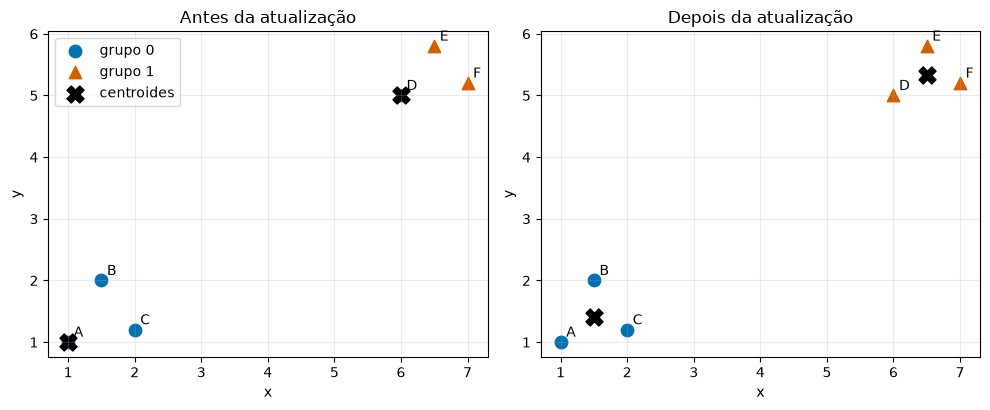

In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4.2))

for eixo, centros, titulo in [
    (eixos[0], centroides_iniciais, "Antes da atualização"),
    (eixos[1], centroides_atualizados, "Depois da atualização"),
]:
    for grupo, marcador, cor in [
        (0, "o", "#0072B2"),
        (1, "^", "#D55E00"),
    ]:
        mascara = grupos == grupo
        eixo.scatter(
            matriz_pontos[mascara, 0],
            matriz_pontos[mascara, 1],
            marker=marcador,
            color=cor,
            s=80,
            label=f"grupo {grupo}",
        )
    eixo.scatter(
        centros[:, 0],
        centros[:, 1],
        marker="X",
        color="#000000",
        s=150,
        label="centroides",
    )
    for indice, nome in enumerate(pontos["objeto"]):
        eixo.annotate(
            nome,
            (matriz_pontos[indice, 0], matriz_pontos[indice, 1]),
            xytext=(4, 4),
            textcoords="offset points",
        )
    eixo.set(title=titulo, xlabel="x", ylabel="y")
    eixo.grid(alpha=0.25)

eixos[0].legend()
plt.tight_layout()
plt.show()

## 5. A escala pode definir os grupos

Considere clientes descritos pelo gasto médio e pelo número de visitas mensais. O gasto varia por centenas; as visitas, por poucas unidades. Na escala bruta, o gasto tende a dominar a distância.

A padronização transforma cada atributo segundo a média e o desvio do conjunto usado no ajuste:

$$
z=\frac{x-\bar{x}}{s}.
$$

Isso coloca atributos em unidades comparáveis, mas também expressa uma escolha: atribuir peso semelhante às variações padronizadas.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
n_por_perfil = 60

clientes = pd.DataFrame({
    "gasto_medio": np.concatenate([
        rng.normal(150, 18, n_por_perfil),
        rng.normal(300, 30, n_por_perfil),
        rng.normal(300, 30, n_por_perfil),
    ]),
    "visitas_mes": np.concatenate([
        rng.normal(18, 1.2, n_por_perfil),
        rng.normal(18, 1.2, n_por_perfil),
        rng.normal(1, 0.6, n_por_perfil),
    ]),
})
clientes["perfil_gerador"] = np.repeat(
    ["econômico frequente", "premium frequente", "premium ocasional"],
    n_por_perfil,
)

X_bruto = clientes[["gasto_medio", "visitas_mes"]]
padronizador = StandardScaler()
X_padronizado = padronizador.fit_transform(X_bruto)

kmeans_bruto = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_bruto)
kmeans_padronizado = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_padronizado)

clientes["grupo_escala_bruta"] = kmeans_bruto.labels_
clientes["grupo_padronizado"] = kmeans_padronizado.labels_

display(pd.crosstab(
    clientes["perfil_gerador"],
    clientes["grupo_escala_bruta"],
    margins=True,
))
pd.crosstab(
    clientes["perfil_gerador"],
    clientes["grupo_padronizado"],
    margins=True,
)

grupo_escala_bruta,0,1,All
perfil_gerador,,,
econômico frequente,0,60,60
premium frequente,60,0,60
premium ocasional,60,0,60
All,120,60,180


grupo_padronizado,0,1,All
perfil_gerador,,,
econômico frequente,60,0,60
premium frequente,60,0,60
premium ocasional,0,60,60
All,120,60,180


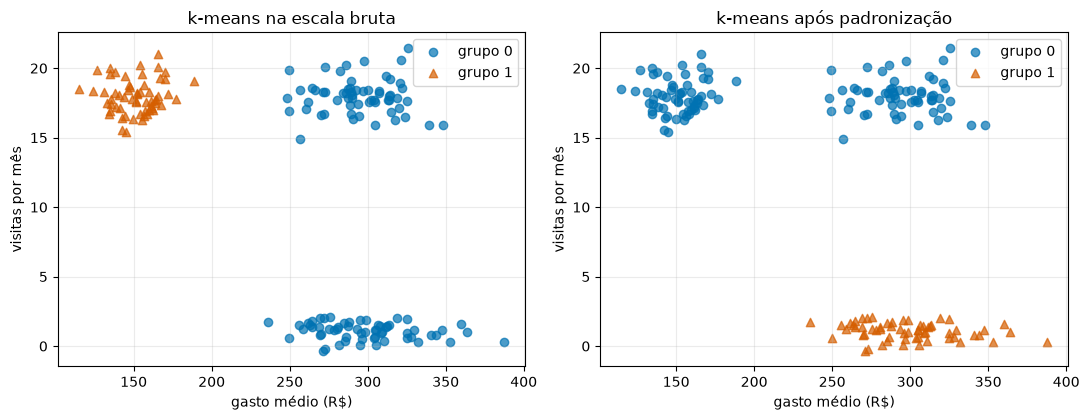

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.3))

for eixo, coluna, titulo in [
    (eixos[0], "grupo_escala_bruta", "k-means na escala bruta"),
    (eixos[1], "grupo_padronizado", "k-means após padronização"),
]:
    for grupo, marcador, cor in [
        (0, "o", "#0072B2"),
        (1, "^", "#D55E00"),
    ]:
        parte = clientes[clientes[coluna] == grupo]
        eixo.scatter(
            parte["gasto_medio"],
            parte["visitas_mes"],
            marker=marcador,
            color=cor,
            alpha=0.70,
            label=f"grupo {grupo}",
        )
    eixo.set(
        title=titulo,
        xlabel="gasto médio (R$)",
        ylabel="visitas por mês",
    )
    eixo.grid(alpha=0.25)
    eixo.legend()

plt.tight_layout()
plt.show()

### Duas partições, duas perguntas implícitas

Na escala bruta, a divisão acompanha principalmente o gasto: clientes econômicos ficam separados dos clientes premium. Após padronização, a frequência ganha peso e a partição destaca os clientes premium ocasionais.

Nenhuma partição é automaticamente “a verdadeira”. A primeira pode ser útil para política de valor; a segunda, para investigar frequência. O perfil gerador aparece apenas para explicar o exemplo sintético e não foi fornecido ao k-means.

## 6. Escolha de $k$ e inicialização

O k-means exige $k$ antes do ajuste. Aumentar $k$ reduz a SSE, porque mais centroides representam os mesmos objetos. Portanto, escolher o menor valor de SSE levaria trivialmente a um grupo por objeto.

O gráfico do “cotovelo” procura uma região em que adicionar grupos passa a reduzir pouco a SSE. Ele é uma pista, não uma decisão automática. A escolha também deve considerar estabilidade, interpretabilidade e utilidade.

A inicialização importa porque soluções locais diferentes podem ser alcançadas. A estratégia k-means++ espalha os centroides iniciais; múltiplas inicializações e escolha da menor SSE reduzem a dependência de uma tentativa.

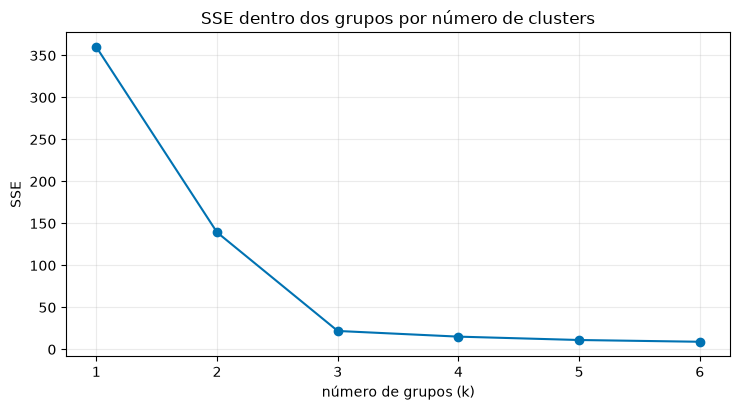

,k,SSE
0,1,360.00
1,2,139.34
2,3,21.90
3,4,15.14
4,5,11.13
5,6,9.03


In [7]:
inercias = []
for k in range(1, 7):
    modelo = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    ).fit(X_padronizado)
    inercias.append({"k": k, "SSE": modelo.inertia_})

tabela_inercias = pd.DataFrame(inercias)

fig, eixo = plt.subplots(figsize=(7.5, 4.2))
eixo.plot(
    tabela_inercias["k"],
    tabela_inercias["SSE"],
    marker="o",
    color="#0072B2",
)
eixo.set(
    title="SSE dentro dos grupos por número de clusters",
    xlabel="número de grupos (k)",
    ylabel="SSE",
    xticks=range(1, 7),
)
eixo.grid(alpha=0.25)
plt.tight_layout()
plt.show()

tabela_inercias.round(2)

## 7. Limitação geométrica: nem todo grupo é uma “bola”

Com distância Euclidiana e centroides, o k-means favorece grupos compactos e convexos. Formas curvas, densidades diferentes e valores atípicos podem produzir partições pouco intuitivas.

O conjunto de “duas luas” abaixo possui dois arcos claros visualmente. Mesmo com $k=2$, o k-means separa o plano por fronteiras lineares entre centroides e corta os arcos.

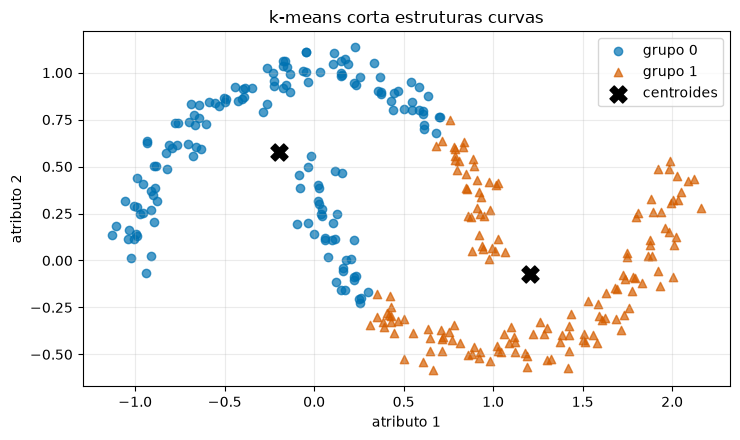

In [8]:
X_luas, _ = make_moons(
    n_samples=300,
    noise=0.06,
    random_state=RANDOM_STATE,
)
modelo_luas = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_luas)

fig, eixo = plt.subplots(figsize=(7.5, 4.5))
for grupo, marcador, cor in [
    (0, "o", "#0072B2"),
    (1, "^", "#D55E00"),
]:
    mascara = modelo_luas.labels_ == grupo
    eixo.scatter(
        X_luas[mascara, 0],
        X_luas[mascara, 1],
        marker=marcador,
        color=cor,
        alpha=0.70,
        label=f"grupo {grupo}",
    )
eixo.scatter(
    modelo_luas.cluster_centers_[:, 0],
    modelo_luas.cluster_centers_[:, 1],
    marker="X",
    color="#000000",
    s=150,
    label="centroides",
)
eixo.set(
    title="k-means corta estruturas curvas",
    xlabel="atributo 1",
    ylabel="atributo 2",
)
eixo.grid(alpha=0.25)
eixo.legend()
plt.tight_layout()
plt.show()

### Quando desconfiar do k-means

- atributos não numéricos sem representação apropriada;
- escalas ou pesos sem justificativa;
- muitos atributos irrelevantes;
- grupos alongados, curvos ou de densidades diferentes;
- presença de valores atípicos que deslocam médias;
- necessidade de permitir ruído ou sobreposição;
- $k$ escolhido apenas por conveniência.

Nessas situações, métodos hierárquicos ou baseados em densidade podem responder melhor, tema do próximo notebook.

## Atividades

> **U06-NB01-V01 — Verifique seu entendimento:** por que os rótulos numéricos 0 e 1 atribuídos pelo k-means não significam ordem, qualidade ou identidade estável entre execuções?

> **U06-NB01-E01 — Exercício manual:** para os seis pontos, reproduza as distâncias da primeira atribuição, os dois centroides atualizados e a SSE antes e depois da atualização. Mostre ao menos uma distância e as duas médias em detalhes.

> **U06-NB01-E02 — Escala e interpretação:** descreva como os três perfis sintéticos foram distribuídos na escala bruta e na padronizada. Explique qual atributo orienta cada solução e proponha um uso legítimo para cada partição.

> **U06-NB01-E03 — Escolha responsável:** usando a tabela do cotovelo, proponha um valor de $k$ e justifique-o sem afirmar que o cotovelo prova a existência desse número de grupos. Inclua duas verificações adicionais.

> **U06-NB01-E04 — Limitação:** explique por que o k-means corta as duas luas. Indique uma característica do método responsável e antecipe uma família de algoritmos mais adequada.

## Síntese

- Agrupamento descreve estrutura sem usar rótulos conhecidos.
- A noção de grupo depende de unidade, atributos, representação, escala e distância.
- O k-means alterna atribuição ao centroide mais próximo e atualização pela média.
- A SSE mede compactação em torno dos centroides e sempre cai com mais grupos.
- Padronização pode mudar profundamente a pergunta respondida.
- Inicializações múltiplas reduzem, mas não eliminam, soluções locais.
- O método favorece grupos compactos e convexos e é sensível a valores atípicos.
- Grupos são hipóteses analíticas a interpretar e validar, não tipos naturais.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 8, seções 8.1 e 8.2.
- SCIKIT-LEARN DEVELOPERS. *User Guide: Clustering — KMeans*. Documentação da biblioteca utilizada nos exemplos computacionais.